In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from scipy.stats import sem

In [2]:
adata_cancer = sc.read_h5ad('cancercell_kinetics_adata.h5ad')

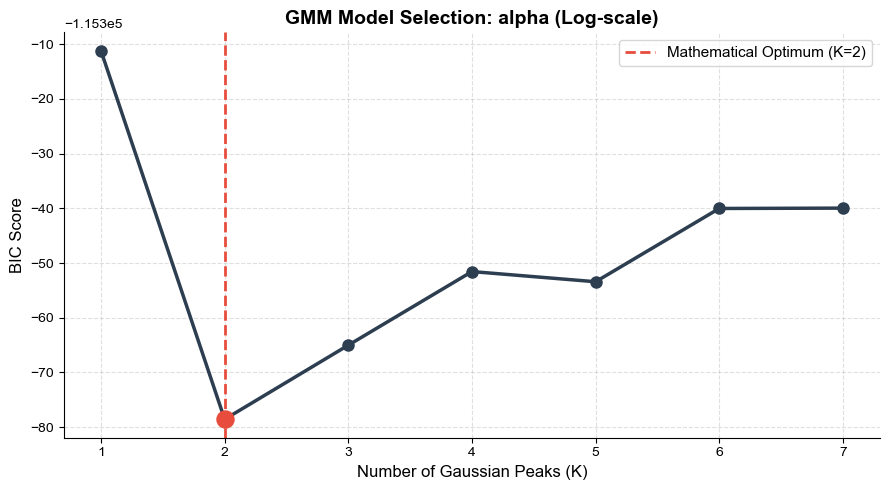


best: 2


In [3]:
# 1.log
feature_col = 'alpha'
data_1d = adata_cancer.obs[feature_col].values.copy()
X_train = np.log1p(data_1d).reshape(-1, 1)

# 2. test GMM K=1 to7
n_components_range = range(1, 8)
bic_scores = []
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=10)
    gmm.fit(X_train)
    bic_scores.append(gmm.bic(X_train))

# 3. BIC 
plt.figure(figsize=(9, 5))
plt.plot(n_components_range, bic_scores, marker='o', color='#2c3e50', linewidth=2.5, markersize=8)
best_n = n_components_range[np.argmin(bic_scores)]
plt.axvline(best_n, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mathematical Optimum (K={best_n})')
plt.scatter(best_n, min(bic_scores), color='#e74c3c', s=150, zorder=5) 
plt.title(f"GMM Model Selection: {feature_col} (Log-scale)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Gaussian Peaks (K)", fontsize=12)
plt.ylabel("BIC Score", fontsize=12)
plt.xticks(n_components_range)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
sns.despine() 
# plt.savefig('CC_GMM_BIC.pdf', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(f"best: {best_n}")

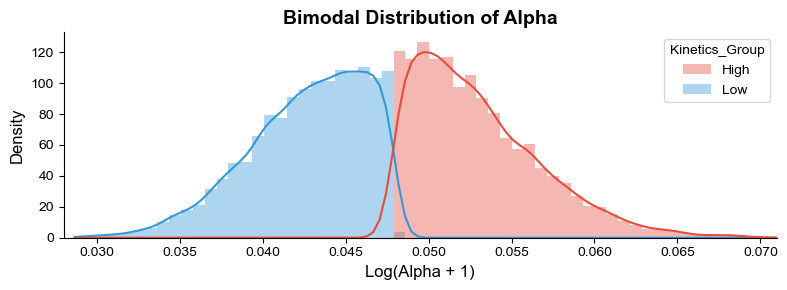

In [4]:
feature_col = 'alpha'
raw_data = adata_cancer.obs[feature_col].values
log_alpha = np.log1p(raw_data).reshape(-1, 1)
# 1. GMM K=2
gmm_1d = GaussianMixture(n_components=2, random_state=42, n_init=10)
labels = gmm_1d.fit_predict(log_alpha)

means = [log_alpha[labels == 0].mean(), log_alpha[labels == 1].mean()]
low_idx = 0 if means[0] < means[1] else 1

df_plot = pd.DataFrame({
    'Log_alpha': log_alpha.flatten(),
    'Kinetics_Group': ['Low' if l == low_idx else 'High' for l in labels]
})
adata_cancer.obs['Kinetics_State'] = df_plot['Kinetics_Group'].values

# 2. histplot
plt.figure(figsize=(8, 3))
# KDE
sns.histplot(
    data=df_plot, 
    x='Log_alpha', 
    hue='Kinetics_Group', 
    kde=True,                  
    palette={'Low': '#3498db', 'High': '#e74c3c'}, 
    alpha=0.4,                 
    stat='density',            
    common_norm=False,         
    linewidth=0                
)

plt.title("Bimodal Distribution of Alpha", fontsize=14, fontweight='bold')
plt.xlabel("Log(Alpha + 1)", fontsize=12)
plt.ylabel("Density", fontsize=12)
sns.despine() 
plt.xlim(0.028, 0.071)
# plt.savefig('Cancer_GMM_KDE.pdf', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()



In [5]:
# 1. dict
cancer_mapping = {
    'cancer1': 'PTC',
    'cancer2': 'ITC',
    'cancer3': 'MTC'
}
adata_cancer.obs['CCtype'] = adata_cancer.obs['celltype1'].map(cancer_mapping)

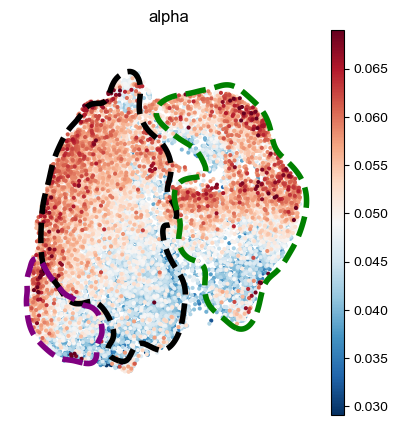

In [6]:
# 1. UMAP
adata_cancer.obs['UMAP1'] = adata_cancer.obsm['X_umap'][:, 0]
adata_cancer.obs['UMAP2'] = adata_cancer.obsm['X_umap'][:, 1]

fig, ax = plt.subplots(figsize=(4.5, 5))
sc.pl.umap(
    adata_cancer, 
    color='alpha', 
    cmap='RdBu_r',
    vmax=0.069,
    s=35, 
    alpha=1, 
    ax=ax, 
    frameon=False,
    show=False
)

contour_colors = {'PTC': 'black', 'ITC': 'green', 'MTC': 'purple'}

for cancer in ['PTC', 'ITC', 'MTC']:
    subset = adata_cancer.obs[adata_cancer.obs['CCtype'] == cancer]
    
    sns.kdeplot(
        data=subset,
        x='UMAP1', y='UMAP2',
        ax=ax,
        levels=[0.13],
        colors=contour_colors[cancer],
        linewidths=4,
        label=cancer,
        alpha=1  ,
        linestyles='--',
        show=False
    )

# plt.savefig('Cancer_cell_sub_alpha_UMAP.pdf', bbox_inches='tight', dpi=300)
plt.show()

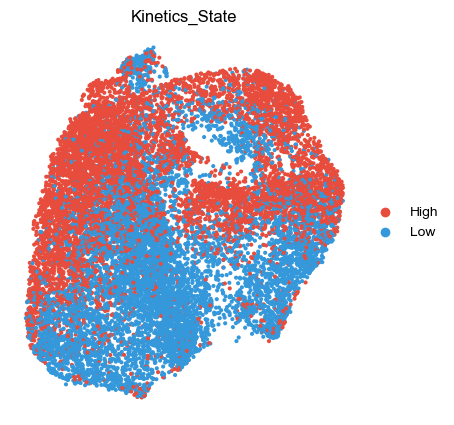

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 5))
sc.pl.umap(
    adata_cancer, 
    color='Kinetics_State', 
    palette={'Low': '#3498db', 'High': '#e74c3c'},
    s=35, 
    alpha=1,
    show=False, 
    ax=ax, 
    frameon=False
)
# plt.savefig('Cancer_cell_GMM_groups_UMAP.pdf', bbox_inches='tight', dpi=300)

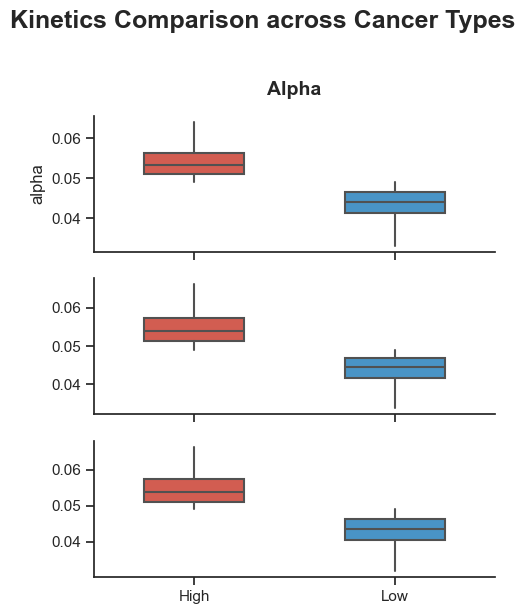

In [8]:
## sub_boxplot_GMMgroups
target_cancers = ['PTC', 'ITC', 'MTC']
plot_data = adata_cancer.obs[
    (adata_cancer.obs['CCtype'].isin(target_cancers)) & 
    (adata_cancer.obs['Kinetics_State'] != 'Filtered_Out')
].copy()

sns.set_theme(style="ticks")
my_palette = {'Low': '#3498db', 'High': '#e74c3c'}
metrics = ['alpha']
metric_names = ['Alpha']

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(5, 6), sharex=True)

#
for i, cancer in enumerate(target_cancers):
    cancer_df = plot_data[plot_data['CCtype'] == cancer]
    
    for j, metric in enumerate(metrics):
        ax = axes[i]

        sns.boxplot(
            data=cancer_df, 
            x='Kinetics_State', 
            y=metric, 
            palette=my_palette,
            width=0.5,
            showfliers=False, 
            capprops={'visible': False},
            ax=ax
        )

        if i == 0:
            ax.set_title(metric_names[j], fontsize=14, fontweight='bold', pad=15)
        else:
            ax.set_ylabel('')
            
        ax.set_xlabel('') 

##
sns.despine()
plt.suptitle('Kinetics Comparison across Cancer Types', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

# plt.savefig('Cancer_cell_sub_alpha_boxplot.pdf', bbox_inches='tight', dpi=300)
plt.show()



In [9]:
adata_cancer.write_h5ad('CC_GMM_groups_adata.h5ad')